importing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

reading csv


In [2]:
df=pd.read_csv('movies.csv')
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0


In [3]:
#is there missing data ?
for col in df.columns:
    pct_missing = round(df[col].isnull().sum() / len(df[col])*100,2)
    print(col,':', pct_missing , '%')

name : 0.0 %
rating : 1.0 %
genre : 0.0 %
year : 0.0 %
released : 0.03 %
score : 0.04 %
votes : 0.04 %
director : 0.0 %
writer : 0.04 %
star : 0.01 %
country : 0.04 %
budget : 28.31 %
gross : 2.46 %
company : 0.22 %
runtime : 0.05 %


In [4]:
df.dtypes

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object

In [5]:
# fill nan values 

for col in ['budget', 'gross', 'runtime', 'score', 'votes']:
    df[col] = df[col].fillna(df[col].median())

for col in ['rating', 'company', 'writer', 'country', 'released', 'star']:
    df[col] = df[col].fillna("Unknown")

In [6]:
# double check missing values
for col in df.columns:
    pct_missing = round(df[col].isnull().sum() / len(df[col])*100,2)
    print(col,':', pct_missing , '%')

name : 0.0 %
rating : 0.0 %
genre : 0.0 %
year : 0.0 %
released : 0.0 %
score : 0.0 %
votes : 0.0 %
director : 0.0 %
writer : 0.0 %
star : 0.0 %
country : 0.0 %
budget : 0.0 %
gross : 0.0 %
company : 0.0 %
runtime : 0.0 %


In [7]:
# change dtypes
df['budget'] = df['budget'].astype('int64')
df['gross'] = df['gross'].astype('int64')

In [8]:
df = df.sort_values(by=['gross'], ascending=False, inplace=False)
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3818,"Love, Honor and Obey",R,Comedy,2000,"February 9, 2001 (United States)",6.5,5200.0,Dominic Anciano,Dominic Anciano,Sadie Frost,United Kingdom,20500000,1400,British Broadcasting Corporation (BBC),103.0
7625,The Untold Story,Unknown,Comedy,2019,"January 11, 2019 (United States)",5.7,320.0,Shane Stanley,Lee Stanley,Miko Hughes,United States,20500000,790,Visual Arts Entertainment,104.0
7580,Run with the Hunted,Not Rated,Crime,2019,"June 26, 2020 (United States)",5.2,735.0,John Swab,John Swab,Ron Perlman,United States,20500000,682,Roxwell Films,93.0
2417,Madadayo,Unknown,Drama,1993,"April 17, 1993 (Japan)",7.3,5100.0,Akira Kurosawa,Ishirô Honda,Tatsuo Matsumura,Japan,11900000,596,DENTSU Music And Entertainment,134.0


collerations


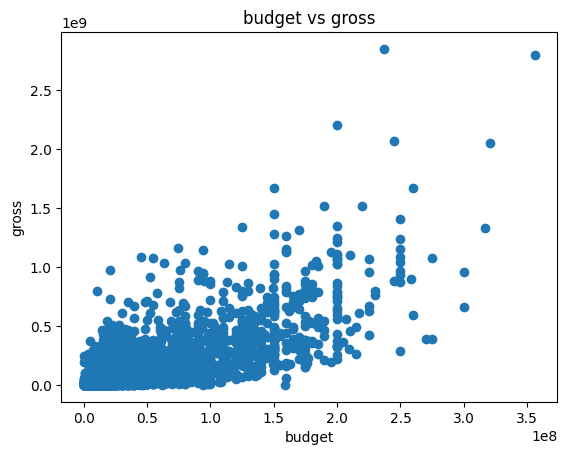

In [9]:
# scatter plot budget vs gross

plt.scatter(x=df['budget'], y=df['gross'])
plt.xlabel('budget')
plt.ylabel('gross')
plt.title('budget vs gross')
plt.show()

<Axes: xlabel='budget', ylabel='gross'>

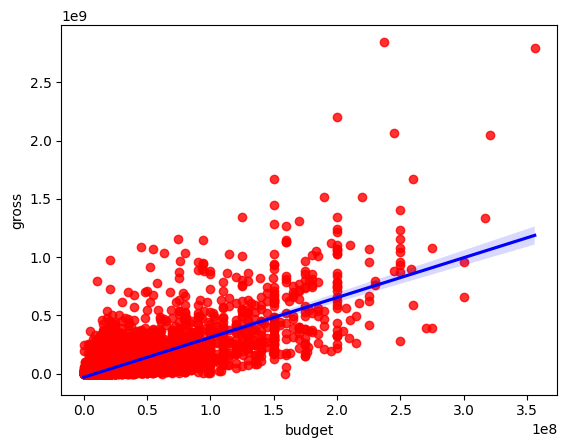

In [10]:
# sns budget vs gross
sns.regplot(x='budget', y='gross', data=df , scatter_kws={'color': 'red', },line_kws={'color': 'blue'})

In [11]:
df.corr(numeric_only=True, method='pearson')

,year,score,votes,budget,gross,runtime
year,1.000000,0.098013,0.222573,0.291690,0.259504,0.120662
score,0.098013,1.000000,0.409157,0.061931,0.185563,0.399407
votes,0.222573,0.409157,1.000000,0.460968,0.632120,0.309151
budget,0.291690,0.061931,0.460968,1.000000,0.745881,0.273371
gross,0.259504,0.185563,0.632120,0.745881,1.000000,0.244380
runtime,0.120662,0.399407,0.309151,0.273371,0.244380,1.000000


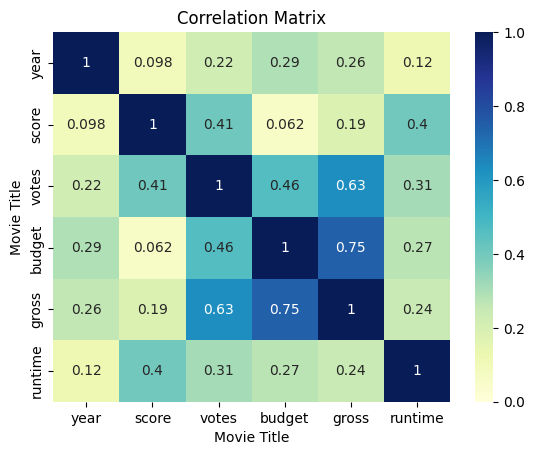

In [12]:
corr_matrix =  df.corr(numeric_only=True, method='pearson')
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', vmin=0, vmax=1)
plt.title('Correlation Matrix')
plt.ylabel('Movie Title')
plt.xlabel('Movie Title')
plt.show()

In [13]:
df_numeric = df.copy()

for col_name in df_numeric.columns:
    if df_numeric[col_name].dtype == 'object':
        df_numeric[col_name] = df_numeric[col_name].astype('category')
        df_numeric[col_name] = df_numeric[col_name].cat.codes
df_numeric        

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
5445,533,5,0,2009,696,7.8,1100000.0,1155,1778,2334,55,237000000,2847246203,2253,162.0
7445,535,5,0,2019,183,8.4,903000.0,162,743,2241,55,356000000,2797501328,1606,181.0
3045,6896,5,6,1997,704,7.8,1100000.0,1155,1778,1595,55,200000000,2201647264,2253,194.0
6663,5144,5,0,2015,698,7.8,876000.0,1125,2550,524,55,245000000,2069521700,1540,138.0
7244,536,5,0,2018,192,8.4,897000.0,162,743,2241,55,321000000,2048359754,1606,149.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3818,3360,6,4,2000,1119,6.5,5200.0,730,1123,2319,54,20500000,1400,477,103.0
7625,6720,10,4,2019,1149,5.7,320.0,2546,2565,1915,55,20500000,790,2309,104.0
7580,4664,3,5,2019,1835,5.2,735.0,1445,2203,2278,55,20500000,682,1992,93.0
2417,3406,10,6,1993,85,7.3,5100.0,33,1718,2563,27,11900000,596,796,134.0


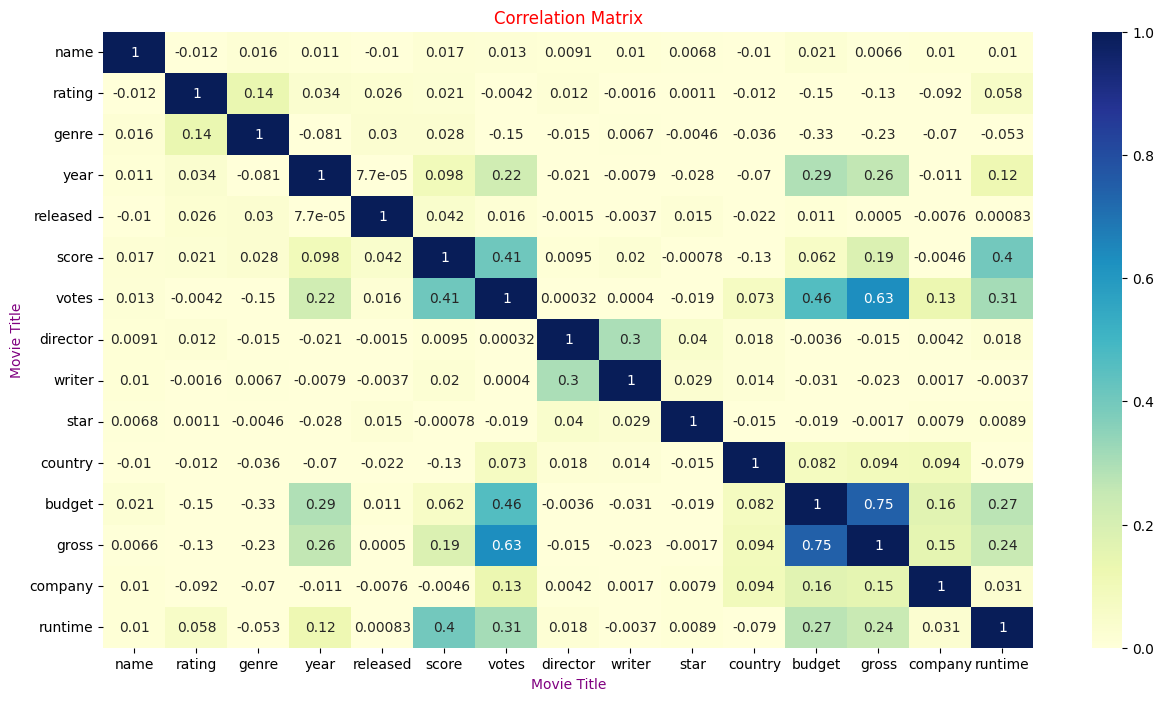

In [14]:
corr_matrix =  df_numeric.corr(method='pearson')
plt.figure(figsize=(15,8))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', vmin=0, vmax=1)
plt.title('Correlation Matrix', color='red')
plt.ylabel('Movie Title' , color='purple')
plt.xlabel('Movie Title', color='purple')
plt.show()

In [15]:
correlation_mat = df_numeric.corr().copy()
corr_pairs = correlation_mat.unstack()
corr_pairs

name     name        1.000000
         rating     -0.012206
         genre       0.016355
         year        0.011453
         released   -0.010480
                       ...   
runtime  country    -0.079230
         budget      0.273371
         gross       0.244380
         company     0.031007
         runtime     1.000000
Length: 225, dtype: float64

In [16]:
sorted_pairs = corr_pairs.sort_values(ascending=False)
sorted_pairs

name     name       1.000000
rating   rating     1.000000
company  company    1.000000
gross    gross      1.000000
budget   budget     1.000000
                      ...   
         rating    -0.149686
genre    gross     -0.233385
gross    genre     -0.233385
genre    budget    -0.328484
budget   genre     -0.328484
Length: 225, dtype: float64

In [17]:
high_corr = sorted_pairs[(sorted_pairs)>0.5]
high_corr

name      name        1.000000
rating    rating      1.000000
company   company     1.000000
gross     gross       1.000000
budget    budget      1.000000
country   country     1.000000
star      star        1.000000
writer    writer      1.000000
votes     votes       1.000000
score     score       1.000000
released  released    1.000000
year      year        1.000000
genre     genre       1.000000
director  director    1.000000
runtime   runtime     1.000000
gross     budget      0.745881
budget    gross       0.745881
votes     gross       0.632120
gross     votes       0.632120
dtype: float64

votes and budget has the highest correlation to gross earnings


In [19]:
high_corr= sorted_pairs[((sorted_pairs) > 0.5) & ((sorted_pairs) < 1)]
important_high_corr = high_corr.drop_duplicates()
important_high_corr = (important_high_corr * 100).round(2).astype(str) + '%'
print(important_high_corr)

gross  budget    74.59%
votes  gross     63.21%
dtype: object
